In [1]:
# ==============================================================================
# 1. INSTALAÇÃO, IMPORTAÇÕES E CONFIGURAÇÃO DE ALTA PERFORMANCE
# ==============================================================================
!pip install roboflow datasets kagglehub -q

import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision
from tensorflow.keras.applications.efficientnet import decode_predictions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from google.colab import files, userdata
from datasets import load_dataset
from roboflow import Roboflow
from concurrent.futures import ThreadPoolExecutor
import kagglehub

# ATIVAÇÃO DE PRECISÃO MISTA (FP16)
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# CONFIGURAÇÕES GERAIS
IMG_SIZE = 160
BATCH_SIZE = 64
DATA_DIR = "/content/unified_pets"

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

print("⚡ Baixando datasets de forma assíncrona...")

# 1.1 Stanford Dogs
rf = Roboflow(api_key=userdata.get('api-roboflow'))
project = rf.workspace("lake-test-company").project("stanford-dogs-dataset-classification")
version = project.version(1)
dataset = version.download("folder")
ROBOFLOW_IMG_DIR = dataset.location if not os.path.exists(os.path.join(dataset.location, "train")) else os.path.join(dataset.location, "train")

# 1.2 Oxford Pets
ds_oxford = load_dataset("enterprise-explorers/oxford-pets", token=userdata.get('api-face'))
raças_gatos_oxford = {'abyssinian', 'bengal', 'birman', 'bombay', 'british_shorthair', 'egyptian_mau', 'maine_coon', 'persian', 'ragdoll', 'russian_blue', 'siamese', 'sphynx'}

# 1.3 Dog's Skin Diseases
os.environ['KAGGLE_USERNAME'] = userdata.get('kaggle-user')
os.environ['KAGGLE_KEY'] = userdata.get('api-kaggle')
KAG_PATH = kagglehub.dataset_download("youssefmohmmed/dogs-skin-diseases-image-dataset")

stanford_classes = set()
skin_disease_classes = set()

# ==============================================================================
# 2. ORGANIZAÇÃO DOS DATASETS (SYMLINKS)
# ==============================================================================
def processar_oxford_paralelo(item):
    i, ex = item
    label = ex['label'].lower().replace(' ', '_')
    if label in raças_gatos_oxford: return
    dest = os.path.join(DATA_DIR, label)
    os.makedirs(dest, exist_ok=True)
    ex['image'].convert('RGB').save(os.path.join(dest, f"ox_{i}.jpg"))

print("⚡ Mapeando arquivos estruturais...")
for folder in os.listdir(ROBOFLOW_IMG_DIR):
    src = os.path.join(ROBOFLOW_IMG_DIR, folder)
    if not os.path.isdir(src): continue
    clean_name = folder.split('-', 1)[-1].lower() if '-' in folder else folder.lower()
    stanford_classes.add(clean_name)
    dest = os.path.join(DATA_DIR, clean_name)
    os.makedirs(dest, exist_ok=True)
    for img in os.listdir(src)[:100]:
        if img.lower().endswith(('.png', '.jpg', '.jpeg')):
            os.symlink(os.path.join(src, img), os.path.join(dest, f"st_{img}"))

with ThreadPoolExecutor() as executor:
    executor.map(processar_oxford_paralelo, enumerate(ds_oxford['train']))

if os.path.exists(KAG_PATH):
    for split in ['train', 'valid', 'test']:
        split_dir = os.path.join(KAG_PATH, split)
        if not os.path.exists(split_dir): continue
        for folder in os.listdir(split_dir):
            src_folder = os.path.join(split_dir, folder)
            if not os.path.isdir(src_folder): continue
            clean_name = folder.lower().replace(' ', '_')
            skin_disease_classes.add(clean_name)
            dest = os.path.join(DATA_DIR, clean_name)
            os.makedirs(dest, exist_ok=True)
            for img in os.listdir(src_folder):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    os.symlink(os.path.join(src_folder, img), os.path.join(dest, f"kg_{split}_{img}"))

# ==============================================================================
# 3. PIPELINE DE DADOS COM CONTRASTE DINÂMICO ADICIONADO
# ==============================================================================
print("\n⚡ Configurando pipeline de dados otimizado...")
train_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR, validation_split=0.2, subset="training", seed=42, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR, validation_split=0.2, subset="validation", seed=42, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)

dataset_map = {}
for name in class_names:
    if name in stanford_classes: dataset_map[name] = "Stanford-Dogs"
    elif name in skin_disease_classes: dataset_map[name] = "Kaggle-Skin-Disease"
    else: dataset_map[name] = "Oxford-Pets"

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# INJEÇÃO DA CAMADA DE CONTRASTE PARA IDENTIFICAÇÃO DE LESÕES
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2)  # Adicionado: Neutraliza variações de luz/flash da câmera
])

# ==============================================================================
# 4. ARQUITETURA
# ==============================================================================
base_model = tf.keras.applications.EfficientNetV2B0(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_aug(inputs)
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
detector_gato = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    input_shape=(224, 224, 3)
)
# ==============================================================================
# 5. TREINAMENTO EM DUAS ETAPAS (FINE-TUNING ATIVADO)
# ==============================================================================
print("\n⚡ [FASE 1] Aquecimento da Cabeça...")
history_warmup = model.fit(train_ds, epochs=8, validation_data=val_ds)

print("\n🔓 [FASE 2] Ativando Fine-Tuning de Camadas Superiores...")
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_fine = model.fit(train_ds, epochs=6, validation_data=val_ds)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 50.7 MB/s eta 0:00:00
⚡ Baixando datasets de forma assíncrona...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Stanford-Dogs-Dataset-Classification-1 in folder:: 100%|██████████| 21918/21918 [00:02<00:00, 8937.52it/s]


README.md:   0%|          | 0.00/565 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.10k [00:00<?, ?B/s]

data/train-00000-of-00001-ecc2afb43dedd5(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7390 [00:00<?, ? examples/s]

100%|██████████| 219M/219M [00:02<00:00, 104MB/s] 

Extracting files...


⚡ Mapeando arquivos estruturais...

⚡ Configurando pipeline de dados otimizado...
Found 21299 files belonging to 137 classes.
Using 17040 files for training.
Found 21299 files belonging to 137 classes.
Using 4259 files for validation.
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

⚡ [FASE 1] Aquecimento da Cabeça...
Epoch 1/8
267/267 ━━━━━━━━━━━━━━━━━━━━ 95s 151ms/step - accuracy: 0.5629 - loss: 1.7860 - val_accuracy: 0.7582 - val_loss: 0.8090
Epoch 2/8
267/267 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.7296 - loss: 0.9092 - val_accuracy: 0.7856 - val_loss: 0.7010
Epoch 3/8
267/267 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.7614 - loss: 0.7887 - val_accuracy: 0.8077 - val_loss: 0.6343
Epoch 4/8
267/267 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.7769 - loss: 0.7138 - val_accuracy: 0.8122 - val_loss: 0.6098
Epoch 5/8
267/267 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.7974 - loss: 0.6490 - val_accuracy: 0.8150

Teste 1 do modelo


🔼 ENVIE A FOTO DO SEU PET:


Saving test3.webp to test3.webp
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📊 RELATÓRIO DE TRIAGEM SEPARADO PARA: 'test3.webp'
🐕 POSSÍVEIS RAÇAS (Top 5):
  1º: Toy Poodle -> 43.68%
  2º: Havanese -> 22.98%
  3º: Wheaten Terrier -> 11.87%
  4º: Miniature Poodle -> 5.49%
  5º: Coated Wheaten Terrier -> 5.08%

🩺 STATUS CLÍNICO DERMATOLÓGICO:
  🔴 ALERTA DE LESÕES CUTÂNEAS DETECTADAS. Possíveis Condições:
    - Fungal Infections: 47.37%
    - Demodicosis: 27.01%
    - Hypersensitivity: 13.75%
    - Ringworm: 3.32%


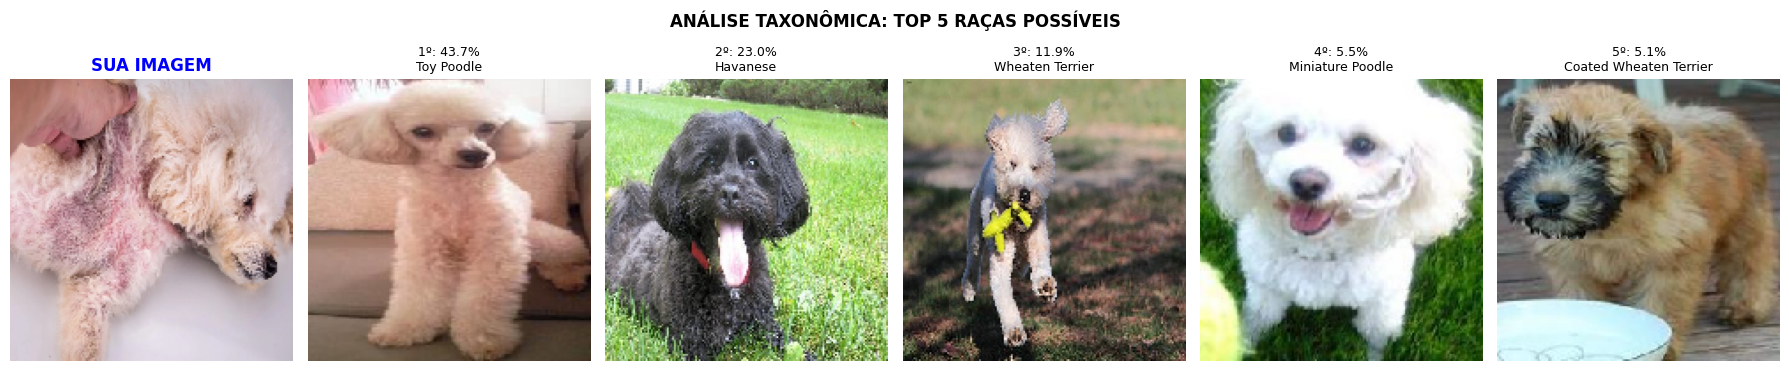

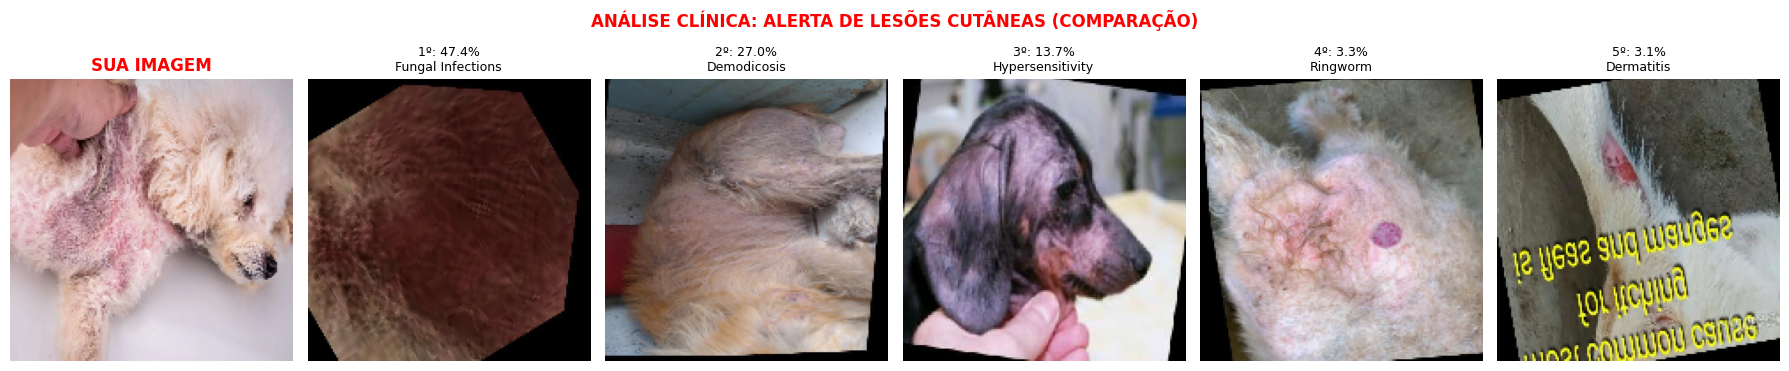

In [3]:
# ==============================================================================
# DIAGNÓSTICO INTERATIVO COM Cachorro
# ==============================================================================
def realizar_diagnostico_com_referencia():
    print("\n🔼 ENVIE A FOTO DO SEU PET:")
    uploaded = files.upload()
    if not uploaded: return

    idx_racas = [i for i, name in enumerate(class_names) if dataset_map[name] in ["Stanford-Dogs", "Oxford-Pets"]]
    idx_doencas = [i for i, name in enumerate(class_names) if dataset_map[name] == "Kaggle-Skin-Disease"]

    for fname in uploaded.keys():
        # Validação preventiva de Felinos
        img_check = tf.keras.utils.load_img(fname, target_size=(224, 224))
        arr_check = tf.keras.utils.img_to_array(img_check)
        arr_check = np.expand_dims(arr_check, axis=0)
        arr_check = tf.keras.applications.efficientnet.preprocess_input(arr_check)
        preds_check = detector_gato.predict(arr_check, verbose=0)
        decoded_check = decode_predictions(preds_check, top=3)[0]
        if any(('cat' in p[1].lower() or 'tabby' in p[1].lower()) and p[2] > 0.15 for p in decoded_check):
            print(f"🐱 Filtro: Elemento felino detectado na foto '{fname}'.")
            continue

        # Predição de Alvo
        img_original = tf.keras.utils.load_img(fname, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img_original)
        img_array = np.expand_dims(img_array, axis=0)
        preds = model.predict(img_array, verbose=0)[0]

        # Separação e Filtros de Grupos
        preds_racas = [(idx, preds[idx]) for idx in idx_racas]
        preds_racas.sort(key=lambda x: x[1], reverse=True)
        top_5_racas = preds_racas[:5]
        soma_racas = sum(p[1] for p in preds_racas) or 1.0

        preds_doencas = [(idx, preds[idx]) for idx in idx_doencas]
        preds_doencas.sort(key=lambda x: x[1], reverse=True)
        top_5_doencas = preds_doencas[:5]
        soma_doencas = sum(p[1] for p in preds_doencas) or 1.0

        top_clinico_nome = class_names[top_5_doencas[0][0]].lower()
        top_clinico_conf_relativa = (top_5_doencas[0][1] / soma_doencas) * 100
        esta_saudavel = (top_clinico_nome == "healthy" and top_clinico_conf_relativa > 70.0)

        # ----------------------------------------------------------------------
        # EXIBIÇÃO EM CONSOLE (LEGENDA E RESULTADOS)
        # ----------------------------------------------------------------------
        print(f"\n{"="*80}\n📊 RELATÓRIO DE TRIAGEM SEPARADO PARA: '{fname}'\n{"="*80}")
        print("🐕 POSSÍVEIS RAÇAS (Top 5):")
        for i, (idx, conf) in enumerate(top_5_racas):
            print(f"  {i+1}º: {class_names[idx].replace('_', ' ').title()} -> {(conf/soma_racas)*100:.2f}%")

        print("\n🩺 STATUS CLÍNICO DERMATOLÓGICO:")
        if esta_saudavel:
            print(f"  🟢 ANÁLISE CLÍNICA DIZ: NENHUMA ANOMALIA DETECTADA (SAUDÁVEL) - Confiança: {top_clinico_conf_relativa:.2f}%")
        else:
            print(f"  🔴 ALERTA DE LESÕES CUTÂNEAS DETECTADAS. Possíveis Condições:")
            for i, (idx, conf) in enumerate(top_5_doencas):
                if class_names[idx].lower() != "healthy":
                    print(f"    - {class_names[idx].replace('_', ' ').title()}: {(conf/soma_doencas)*100:.2f}%")

        # ----------------------------------------------------------------------
        # EXIBIÇÃO GRÁFICA INTELIGENTE (UX CORRIGIDA)
        # ----------------------------------------------------------------------
        # Linha Única: Mostra a sua imagem original e as referências de raças
        fig_raca, axes_raca = plt.subplots(1, 6, figsize=(18, 3.5))
        axes_raca[0].imshow(img_original)
        axes_raca[0].set_title("SUA IMAGEM", fontweight='bold', color='blue')
        axes_raca[0].axis('off')

        for i, (idx, conf) in enumerate(top_5_racas):
            raca_nome = class_names[idx]
            raca_folder = os.path.join(DATA_DIR, raca_nome)
            ex_img = [f for f in os.listdir(raca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
            img_exemplo = tf.keras.utils.load_img(os.path.join(raca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

            axes_raca[i+1].imshow(img_exemplo)
            axes_raca[i+1].set_title(f"{i+1}º: {(conf/soma_racas)*100:.1f}%\n{raca_nome.replace('_', ' ').title()}", fontsize=9)
            axes_raca[i+1].axis('off')
        fig_raca.suptitle("ANÁLISE TAXONÔMICA: TOP 5 RAÇAS POSSÍVEIS", fontsize=12, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

        # Se NÃO estiver saudável, criamos o segundo bloco de imagens para comparação de patologias
        if not esta_saudavel:
            fig_doenca, axes_doenca = plt.subplots(1, 6, figsize=(18, 3.5))
            axes_doenca[0].imshow(img_original)
            axes_doenca[0].set_title("SUA IMAGEM", fontweight='bold', color='red')
            axes_doenca[0].axis('off')

            doencas_filtradas = [p for p in preds_doencas if class_names[p[0]].lower() != "healthy"][:5]
            for i, (idx, conf) in enumerate(doencas_filtradas):
                doenca_nome = class_names[idx]
                doenca_folder = os.path.join(DATA_DIR, doenca_nome)
                ex_img = [f for f in os.listdir(doenca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
                img_exemplo = tf.keras.utils.load_img(os.path.join(doenca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

                axes_doenca[i+1].imshow(img_exemplo)
                axes_doenca[i+1].set_title(f"{i+1}º: {(conf/soma_doencas)*100:.1f}%\n{doenca_nome.replace('_', ' ').title()}", fontsize=9)
                axes_doenca[i+1].axis('off')
            fig_doenca.suptitle("ANÁLISE CLÍNICA: ALERTA DE LESÕES CUTÂNEAS (COMPARAÇÃO)", fontsize=12, fontweight='bold', color='red', y=1.05)
            plt.tight_layout()
            plt.show()

realizar_diagnostico_com_referencia()

Teste 2 do modelo

In [4]:
# ==============================================================================
# DIAGNÓSTICO INTERATIVO COM GATO
# ==============================================================================
def realizar_diagnostico_com_referencia():
    print("\n🔼 ENVIE A FOTO DO SEU PET:")
    uploaded = files.upload()
    if not uploaded: return

    idx_racas = [i for i, name in enumerate(class_names) if dataset_map[name] in ["Stanford-Dogs", "Oxford-Pets"]]
    idx_doencas = [i for i, name in enumerate(class_names) if dataset_map[name] == "Kaggle-Skin-Disease"]

    for fname in uploaded.keys():
        # Validação preventiva de Felinos
        img_check = tf.keras.utils.load_img(fname, target_size=(224, 224))
        arr_check = tf.keras.utils.img_to_array(img_check)
        arr_check = np.expand_dims(arr_check, axis=0)
        arr_check = tf.keras.applications.efficientnet.preprocess_input(arr_check)
        preds_check = detector_gato.predict(arr_check, verbose=0)
        decoded_check = decode_predictions(preds_check, top=3)[0]
        if any(('cat' in p[1].lower() or 'tabby' in p[1].lower()) and p[2] > 0.15 for p in decoded_check):
            print(f"🐱 Filtro: Elemento felino detectado na foto '{fname}'.")
            continue

        # Predição de Alvo
        img_original = tf.keras.utils.load_img(fname, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img_original)
        img_array = np.expand_dims(img_array, axis=0)
        preds = model.predict(img_array, verbose=0)[0]

        # Separação e Filtros de Grupos
        preds_racas = [(idx, preds[idx]) for idx in idx_racas]
        preds_racas.sort(key=lambda x: x[1], reverse=True)
        top_5_racas = preds_racas[:5]
        soma_racas = sum(p[1] for p in preds_racas) or 1.0

        preds_doencas = [(idx, preds[idx]) for idx in idx_doencas]
        preds_doencas.sort(key=lambda x: x[1], reverse=True)
        top_5_doencas = preds_doencas[:5]
        soma_doencas = sum(p[1] for p in preds_doencas) or 1.0

        top_clinico_nome = class_names[top_5_doencas[0][0]].lower()
        top_clinico_conf_relativa = (top_5_doencas[0][1] / soma_doencas) * 100
        esta_saudavel = (top_clinico_nome == "healthy" and top_clinico_conf_relativa > 70.0)

        # ----------------------------------------------------------------------
        # EXIBIÇÃO EM CONSOLE (LEGENDA E RESULTADOS)
        # ----------------------------------------------------------------------
        print(f"\n{"="*80}\n📊 RELATÓRIO DE TRIAGEM SEPARADO PARA: '{fname}'\n{"="*80}")
        print("🐕 POSSÍVEIS RAÇAS (Top 5):")
        for i, (idx, conf) in enumerate(top_5_racas):
            print(f"  {i+1}º: {class_names[idx].replace('_', ' ').title()} -> {(conf/soma_racas)*100:.2f}%")

        print("\n🩺 STATUS CLÍNICO DERMATOLÓGICO:")
        if esta_saudavel:
            print(f"  🟢 ANÁLISE CLÍNICA DIZ: NENHUMA ANOMALIA DETECTADA (SAUDÁVEL) - Confiança: {top_clinico_conf_relativa:.2f}%")
        else:
            print(f"  🔴 ALERTA DE LESÕES CUTÂNEAS DETECTADAS. Possíveis Condições:")
            for i, (idx, conf) in enumerate(top_5_doencas):
                if class_names[idx].lower() != "healthy":
                    print(f"    - {class_names[idx].replace('_', ' ').title()}: {(conf/soma_doencas)*100:.2f}%")

        # ----------------------------------------------------------------------
        # EXIBIÇÃO GRÁFICA INTELIGENTE (UX CORRIGIDA)
        # ----------------------------------------------------------------------
        # Linha Única: Mostra a sua imagem original e as referências de raças
        fig_raca, axes_raca = plt.subplots(1, 6, figsize=(18, 3.5))
        axes_raca[0].imshow(img_original)
        axes_raca[0].set_title("SUA IMAGEM", fontweight='bold', color='blue')
        axes_raca[0].axis('off')

        for i, (idx, conf) in enumerate(top_5_racas):
            raca_nome = class_names[idx]
            raca_folder = os.path.join(DATA_DIR, raca_nome)
            ex_img = [f for f in os.listdir(raca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
            img_exemplo = tf.keras.utils.load_img(os.path.join(raca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

            axes_raca[i+1].imshow(img_exemplo)
            axes_raca[i+1].set_title(f"{i+1}º: {(conf/soma_racas)*100:.1f}%\n{raca_nome.replace('_', ' ').title()}", fontsize=9)
            axes_raca[i+1].axis('off')
        fig_raca.suptitle("ANÁLISE TAXONÔMICA: TOP 5 RAÇAS POSSÍVEIS", fontsize=12, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

        # Se NÃO estiver saudável, criamos o segundo bloco de imagens para comparação de patologias
        if not esta_saudavel:
            fig_doenca, axes_doenca = plt.subplots(1, 6, figsize=(18, 3.5))
            axes_doenca[0].imshow(img_original)
            axes_doenca[0].set_title("SUA IMAGEM", fontweight='bold', color='red')
            axes_doenca[0].axis('off')

            doencas_filtradas = [p for p in preds_doencas if class_names[p[0]].lower() != "healthy"][:5]
            for i, (idx, conf) in enumerate(doencas_filtradas):
                doenca_nome = class_names[idx]
                doenca_folder = os.path.join(DATA_DIR, doenca_nome)
                ex_img = [f for f in os.listdir(doenca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
                img_exemplo = tf.keras.utils.load_img(os.path.join(doenca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

                axes_doenca[i+1].imshow(img_exemplo)
                axes_doenca[i+1].set_title(f"{i+1}º: {(conf/soma_doencas)*100:.1f}%\n{doenca_nome.replace('_', ' ').title()}", fontsize=9)
                axes_doenca[i+1].axis('off')
            fig_doenca.suptitle("ANÁLISE CLÍNICA: ALERTA DE LESÕES CUTÂNEAS (COMPARAÇÃO)", fontsize=12, fontweight='bold', color='red', y=1.05)
            plt.tight_layout()
            plt.show()

realizar_diagnostico_com_referencia()


🔼 ENVIE A FOTO DO SEU PET:


Saving test2.png to test2.png
🐱 Filtro: Elemento felino detectado na foto 'test2.png'.


TESTE 3 do modelo


🔼 ENVIE A FOTO DO SEU PET:


Saving test1.jpg to test1.jpg

📊 RELATÓRIO DE TRIAGEM SEPARADO PARA: 'test1.jpg'
🐕 POSSÍVEIS RAÇAS (Top 5):
  1º: Malamute -> 69.12%
  2º: Siberian Husky -> 18.76%
  3º: Eskimo Dog -> 10.41%
  4º: Norwegian Elkhound -> 1.00%
  5º: Samoyed -> 0.17%

🩺 STATUS CLÍNICO DERMATOLÓGICO:
  🟢 ANÁLISE CLÍNICA DIZ: NENHUMA ANOMALIA DETECTADA (SAUDÁVEL) - Confiança: 99.56%


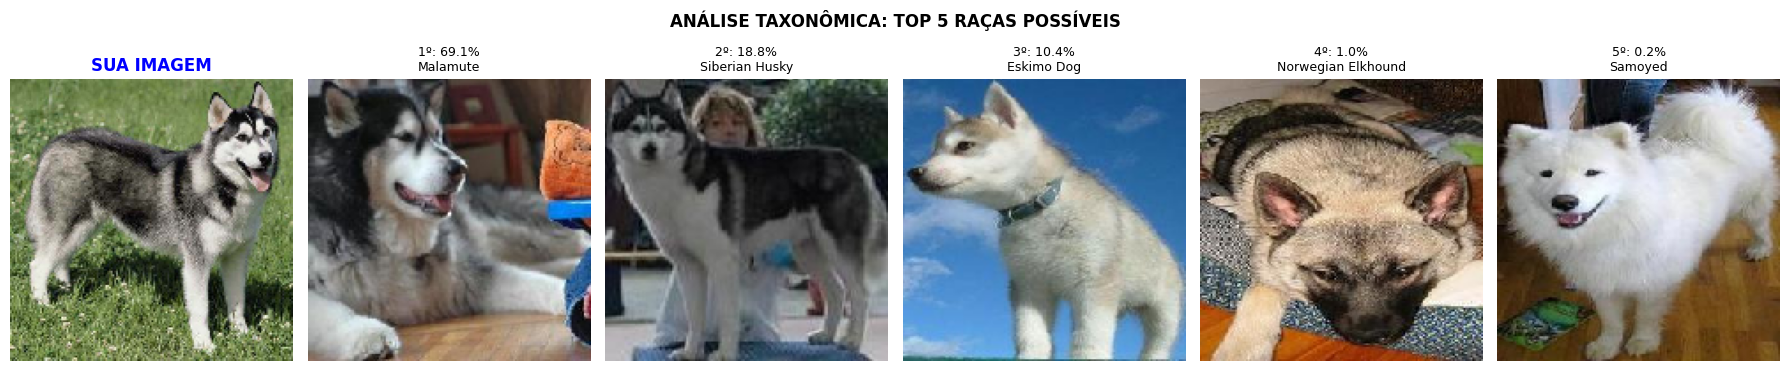

In [5]:
# ==============================================================================
# DIAGNÓSTICO INTERATIVO COM CACHORRO SAUDÁVEL
# ==============================================================================
def realizar_diagnostico_com_referencia():
    print("\n🔼 ENVIE A FOTO DO SEU PET:")
    uploaded = files.upload()
    if not uploaded: return

    idx_racas = [i for i, name in enumerate(class_names) if dataset_map[name] in ["Stanford-Dogs", "Oxford-Pets"]]
    idx_doencas = [i for i, name in enumerate(class_names) if dataset_map[name] == "Kaggle-Skin-Disease"]

    for fname in uploaded.keys():
        # Validação preventiva de Felinos
        img_check = tf.keras.utils.load_img(fname, target_size=(224, 224))
        arr_check = tf.keras.utils.img_to_array(img_check)
        arr_check = np.expand_dims(arr_check, axis=0)
        arr_check = tf.keras.applications.efficientnet.preprocess_input(arr_check)
        preds_check = detector_gato.predict(arr_check, verbose=0)
        decoded_check = decode_predictions(preds_check, top=3)[0]
        if any(('cat' in p[1].lower() or 'tabby' in p[1].lower()) and p[2] > 0.15 for p in decoded_check):
            print(f"🐱 Filtro: Elemento felino detectado na foto '{fname}'.")
            continue

        # Predição de Alvo
        img_original = tf.keras.utils.load_img(fname, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img_original)
        img_array = np.expand_dims(img_array, axis=0)
        preds = model.predict(img_array, verbose=0)[0]

        # Separação e Filtros de Grupos
        preds_racas = [(idx, preds[idx]) for idx in idx_racas]
        preds_racas.sort(key=lambda x: x[1], reverse=True)
        top_5_racas = preds_racas[:5]
        soma_racas = sum(p[1] for p in preds_racas) or 1.0

        preds_doencas = [(idx, preds[idx]) for idx in idx_doencas]
        preds_doencas.sort(key=lambda x: x[1], reverse=True)
        top_5_doencas = preds_doencas[:5]
        soma_doencas = sum(p[1] for p in preds_doencas) or 1.0

        top_clinico_nome = class_names[top_5_doencas[0][0]].lower()
        top_clinico_conf_relativa = (top_5_doencas[0][1] / soma_doencas) * 100
        esta_saudavel = (top_clinico_nome == "healthy" and top_clinico_conf_relativa > 70.0)

        # ----------------------------------------------------------------------
        # EXIBIÇÃO EM CONSOLE (LEGENDA E RESULTADOS)
        # ----------------------------------------------------------------------
        print(f"\n{"="*80}\n📊 RELATÓRIO DE TRIAGEM SEPARADO PARA: '{fname}'\n{"="*80}")
        print("🐕 POSSÍVEIS RAÇAS (Top 5):")
        for i, (idx, conf) in enumerate(top_5_racas):
            print(f"  {i+1}º: {class_names[idx].replace('_', ' ').title()} -> {(conf/soma_racas)*100:.2f}%")

        print("\n🩺 STATUS CLÍNICO DERMATOLÓGICO:")
        if esta_saudavel:
            print(f"  🟢 ANÁLISE CLÍNICA DIZ: NENHUMA ANOMALIA DETECTADA (SAUDÁVEL) - Confiança: {top_clinico_conf_relativa:.2f}%")
        else:
            print(f"  🔴 ALERTA DE LESÕES CUTÂNEAS DETECTADAS. Possíveis Condições:")
            for i, (idx, conf) in enumerate(top_5_doencas):
                if class_names[idx].lower() != "healthy":
                    print(f"    - {class_names[idx].replace('_', ' ').title()}: {(conf/soma_doencas)*100:.2f}%")

        # ----------------------------------------------------------------------
        # EXIBIÇÃO GRÁFICA INTELIGENTE (UX CORRIGIDA)
        # ----------------------------------------------------------------------
        # Linha Única: Mostra a sua imagem original e as referências de raças
        fig_raca, axes_raca = plt.subplots(1, 6, figsize=(18, 3.5))
        axes_raca[0].imshow(img_original)
        axes_raca[0].set_title("SUA IMAGEM", fontweight='bold', color='blue')
        axes_raca[0].axis('off')

        for i, (idx, conf) in enumerate(top_5_racas):
            raca_nome = class_names[idx]
            raca_folder = os.path.join(DATA_DIR, raca_nome)
            ex_img = [f for f in os.listdir(raca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
            img_exemplo = tf.keras.utils.load_img(os.path.join(raca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

            axes_raca[i+1].imshow(img_exemplo)
            axes_raca[i+1].set_title(f"{i+1}º: {(conf/soma_racas)*100:.1f}%\n{raca_nome.replace('_', ' ').title()}", fontsize=9)
            axes_raca[i+1].axis('off')
        fig_raca.suptitle("ANÁLISE TAXONÔMICA: TOP 5 RAÇAS POSSÍVEIS", fontsize=12, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

        # Se NÃO estiver saudável, criamos o segundo bloco de imagens para comparação de patologias
        if not esta_saudavel:
            fig_doenca, axes_doenca = plt.subplots(1, 6, figsize=(18, 3.5))
            axes_doenca[0].imshow(img_original)
            axes_doenca[0].set_title("SUA IMAGEM", fontweight='bold', color='red')
            axes_doenca[0].axis('off')

            doencas_filtradas = [p for p in preds_doencas if class_names[p[0]].lower() != "healthy"][:5]
            for i, (idx, conf) in enumerate(doencas_filtradas):
                doenca_nome = class_names[idx]
                doenca_folder = os.path.join(DATA_DIR, doenca_nome)
                ex_img = [f for f in os.listdir(doenca_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
                img_exemplo = tf.keras.utils.load_img(os.path.join(doenca_folder, ex_img), target_size=(IMG_SIZE, IMG_SIZE))

                axes_doenca[i+1].imshow(img_exemplo)
                axes_doenca[i+1].set_title(f"{i+1}º: {(conf/soma_doencas)*100:.1f}%\n{doenca_nome.replace('_', ' ').title()}", fontsize=9)
                axes_doenca[i+1].axis('off')
            fig_doenca.suptitle("ANÁLISE CLÍNICA: ALERTA DE LESÕES CUTÂNEAS (COMPARAÇÃO)", fontsize=12, fontweight='bold', color='red', y=1.05)
            plt.tight_layout()
            plt.show()

realizar_diagnostico_com_referencia()

Célula completa de empacotamento para deploy

In [2]:
# ==============================================================================
# EXPORTAÇÃO PARA TESTE LOCAL - PARTE 1
# ==============================================================================

import os
import json
import shutil

EXPORT_DIR = "/content/pet_ai_model"

# Remove exportação antiga
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)

os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(os.path.join(EXPORT_DIR, "references"), exist_ok=True)

print("📦 Exportando modelo...")

# ------------------------------------------------------------------------------
# Modelo
# ------------------------------------------------------------------------------
model.save(os.path.join(EXPORT_DIR, "pet_model.keras"))

print("✅ Modelo salvo.")

# ------------------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------------------
labels = {
    "classes": class_names
}

with open(os.path.join(EXPORT_DIR, "labels.json"), "w") as f:
    json.dump(labels, f, indent=4)

print("✅ labels.json salvo.")

# ------------------------------------------------------------------------------
# Dataset Map
# ------------------------------------------------------------------------------
with open(os.path.join(EXPORT_DIR, "dataset_map.json"), "w") as f:
    json.dump(dataset_map, f, indent=4)

print("✅ dataset_map.json salvo.")

# ==============================================================================
# EXPORTAÇÃO PARA TESTE LOCAL - PARTE 2
# COPIAR UMA IMAGEM DE REFERÊNCIA DE CADA CLASSE
# ==============================================================================

import shutil

print("🖼 Copiando imagens de referência...")

REF_DIR = os.path.join(EXPORT_DIR, "references")

copiadas = 0

for classe in class_names:

    pasta = os.path.join(DATA_DIR, classe)

    if not os.path.exists(pasta):
        continue

    imagens = sorted([
        f for f in os.listdir(pasta)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ])

    if len(imagens) == 0:
        continue

    origem = os.path.join(pasta, imagens[0])

    extensao = os.path.splitext(imagens[0])[1]

    destino = os.path.join(
        REF_DIR,
        classe + extensao
    )

    try:
        # copia o arquivo real (funciona mesmo sendo symlink)
        shutil.copyfile(os.path.realpath(origem), destino)
        copiadas += 1

    except Exception as e:
        print(f"Erro em {classe}: {e}")

print(f"✅ {copiadas} imagens copiadas.")

# ==============================================================================
# EXPORTAÇÃO PARA TESTE LOCAL - PARTE 3
# COMPACTAR E BAIXAR
# ==============================================================================

import os
import shutil

ZIP_FILE = "/content/pet_ai_model.zip"

if os.path.exists(ZIP_FILE):
    os.remove(ZIP_FILE)

print("📦 Compactando arquivos...")

shutil.make_archive(
    ZIP_FILE.replace(".zip", ""),
    "zip",
    EXPORT_DIR
)

print("✅ Arquivo criado com sucesso!")
print(ZIP_FILE)

# ------------------------------------------------------------------------------
# DOWNLOAD
# ------------------------------------------------------------------------------

from google.colab import files

files.download(ZIP_FILE)

📦 Exportando modelo...
✅ Modelo salvo.
✅ labels.json salvo.
✅ dataset_map.json salvo.
🖼 Copiando imagens de referência...
✅ 137 imagens copiadas.
📦 Compactando arquivos...
✅ Arquivo criado com sucesso!
/content/pet_ai_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>